# Introduction to Data Science 2022

# Week 2

In [1]:
import json
from collections import defaultdict
from typing import Union, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer

In [2]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="background-color: #ccfff2"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in Moodle.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle, and complete the following exercises. You will need to create a Kaggle account unless you already have one, but it is quite straightforward. 

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data. 

    <span style="background-color: #ccfff2"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="background-color: #ccfff2"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [3]:
df = pd.read_csv("res/train.csv")
df.shape

(891, 12)

2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="background-color: #ccfff2"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="background-color: #ccfff2"> *Hint: The shape of the data should now be (891, 9).*</span>

In [4]:
df = df.drop(columns=['Name', 'PassengerId', 'Ticket'])
df.shape

(891, 9)

3. The column <span style="background-color: #ccfff2">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="background-color: #ccfff2">*Cabin*</span>-column.

<span style="background-color: #ccfff2">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [5]:
def _f_extract_deck(cabin: Union[str, float]) -> str:
    if cabin is np.nan:
        return np.nan
    
    return cabin[0]

df['Deck'] = df['Cabin'].apply(_f_extract_deck)

df.drop(columns=['Cabin'], inplace=True)

4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="background-color: #ccfff2">*Hint: Pandas can do this for you.*</span>

In [6]:
cols_cat = set(["Pclass", "Sex", "Embarked", "Deck"])
cols_num = set(["Age", "SibSp", "Parch", "Fare"])

In [7]:
def categorize(df: pd.DataFrame, column: str) -> pd.DataFrame:
    assert column in df

    non_nan_vals = df[column].dropna()
    non_nan_ind = non_nan_vals.index

    df.loc[non_nan_ind, column] = LabelEncoder().fit_transform(non_nan_vals)

    return df

df = categorize(df, 'Embarked')
df = categorize(df, 'Deck')
df = categorize(df, 'Sex')

5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="background-color: #ccfff2">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [8]:
# NOTE: HoangLe [Sep-12]: Reason I separate 2 datasets from this step because data imputation for each dataset is better

df_survive = df[df['Survived'] == 1]
df_pass = df[df['Survived'] == 0]

nan_cols = ['Age', 'Embarked', 'Deck']

# Fill na of Deck
def fill_na(df: pd.DataFrame, col: str):
    assert col in df
    if col in cols_cat:
        df[col].fillna(df[col].mode()[0], inplace=True)
    elif col in cols_num:
        df[col].fillna(df[col].mean().item(), inplace=True)
    else:
        raise ValueError(f"Cannot determine type of 'col_name': {col}")

for col in nan_cols:
    fill_na(df_survive, col)
    fill_na(df_pass, col)

/var/folders/pr/8dv_cj95295bxt_hr8hzrmk40000gn/T/ipykernel_19662/1877442721.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].mean().item(), inplace=True)
/var/folders/pr/8dv_cj95295bxt_hr8hzrmk40000gn/T/ipykernel_19662/1877442721.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].mode()[0], inplace=True)


6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="background-color: #ccfff2"> .csv</span> file. Then, write another file, this time in <span style="background-color: #ccfff2">JSON</span> format, with the following structure:

In [9]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [10]:
df_tmp = pd.concat([df_survive, df_pass])

df_tmp.to_csv("titanic_train_processed.csv", index=False)
df_tmp.to_json('titanic_train_processed.json', orient='records', indent=2)

Study the records and try to see if there is any evident pattern in terms of chances of survival.

**Remember to submit your code on Moodle. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [11]:
for col in cols_cat:
    print(f"=> Cat: {col:<10}: mode: {df_tmp[col].mode().item()}")

for col in cols_num:
    print(f"=> Num: {col:<10}: mean: {df_tmp[col].mean().item():7.4f}")

=> Cat: Sex       : mode: 1
=> Cat: Embarked  : mode: 2
=> Cat: Deck      : mode: 2
=> Cat: Pclass    : mode: 3
=> Num: Age       : mean: 29.7501
=> Num: Fare      : mean: 32.2042
=> Num: Parch     : mean:  0.3816
=> Num: SibSp     : mean:  0.5230


2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="background-color: #ccfff2">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="background-color: #ccfff2">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [12]:
df_survive.loc[:, 'imaginary_ave'] = df_survive.drop(columns=['Survived']).mean(axis=1)
df_pass.loc[:, 'imaginary_ave'] = df_pass.drop(columns=['Survived']).mean(axis=1)

print(f"=> Imaginary average of survived: {df_survive['imaginary_ave'].mean():7.4f}")
print(f"=> Imaginary average of passed  : {df_pass['imaginary_ave'].mean():7.4f}")

=> Imaginary average of survived: 10.3596
=> Imaginary average of passed  :  7.5871


/var/folders/pr/8dv_cj95295bxt_hr8hzrmk40000gn/T/ipykernel_19662/1087552899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_survive.loc[:, 'imaginary_ave'] = df_survive.drop(columns=['Survived']).mean(axis=1)
/var/folders/pr/8dv_cj95295bxt_hr8hzrmk40000gn/T/ipykernel_19662/1087552899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pass.loc[:, 'imaginary_ave'] = df_pass.drop(columns=['Survived']).mean(axis=1)


In [13]:
df_survive.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,imaginary_ave
1,1,1,0,38.0,1,0,71.2833,0,2,14.160412
2,1,3,0,26.0,0,0,7.9250,2,1,4.990625
3,1,1,0,35.0,1,0,53.1000,2,2,11.7625
8,1,3,0,27.0,0,2,11.1333,2,1,5.766662
9,1,2,0,14.0,1,0,30.0708,0,1,6.00885


In [14]:
df_pass.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,imaginary_ave
0,0,3,1,22.000000,1,0,7.2500,2,2,4.78125
4,0,3,1,35.000000,0,0,8.0500,2,2,6.38125
5,0,3,1,30.626179,0,0,8.4583,1,2,5.76056
6,0,1,1,54.000000,0,0,51.8625,2,4,14.232812
7,0,3,1,2.000000,3,1,21.0750,2,2,4.384375


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group? 

    <span style="background-color: #ccfff2">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

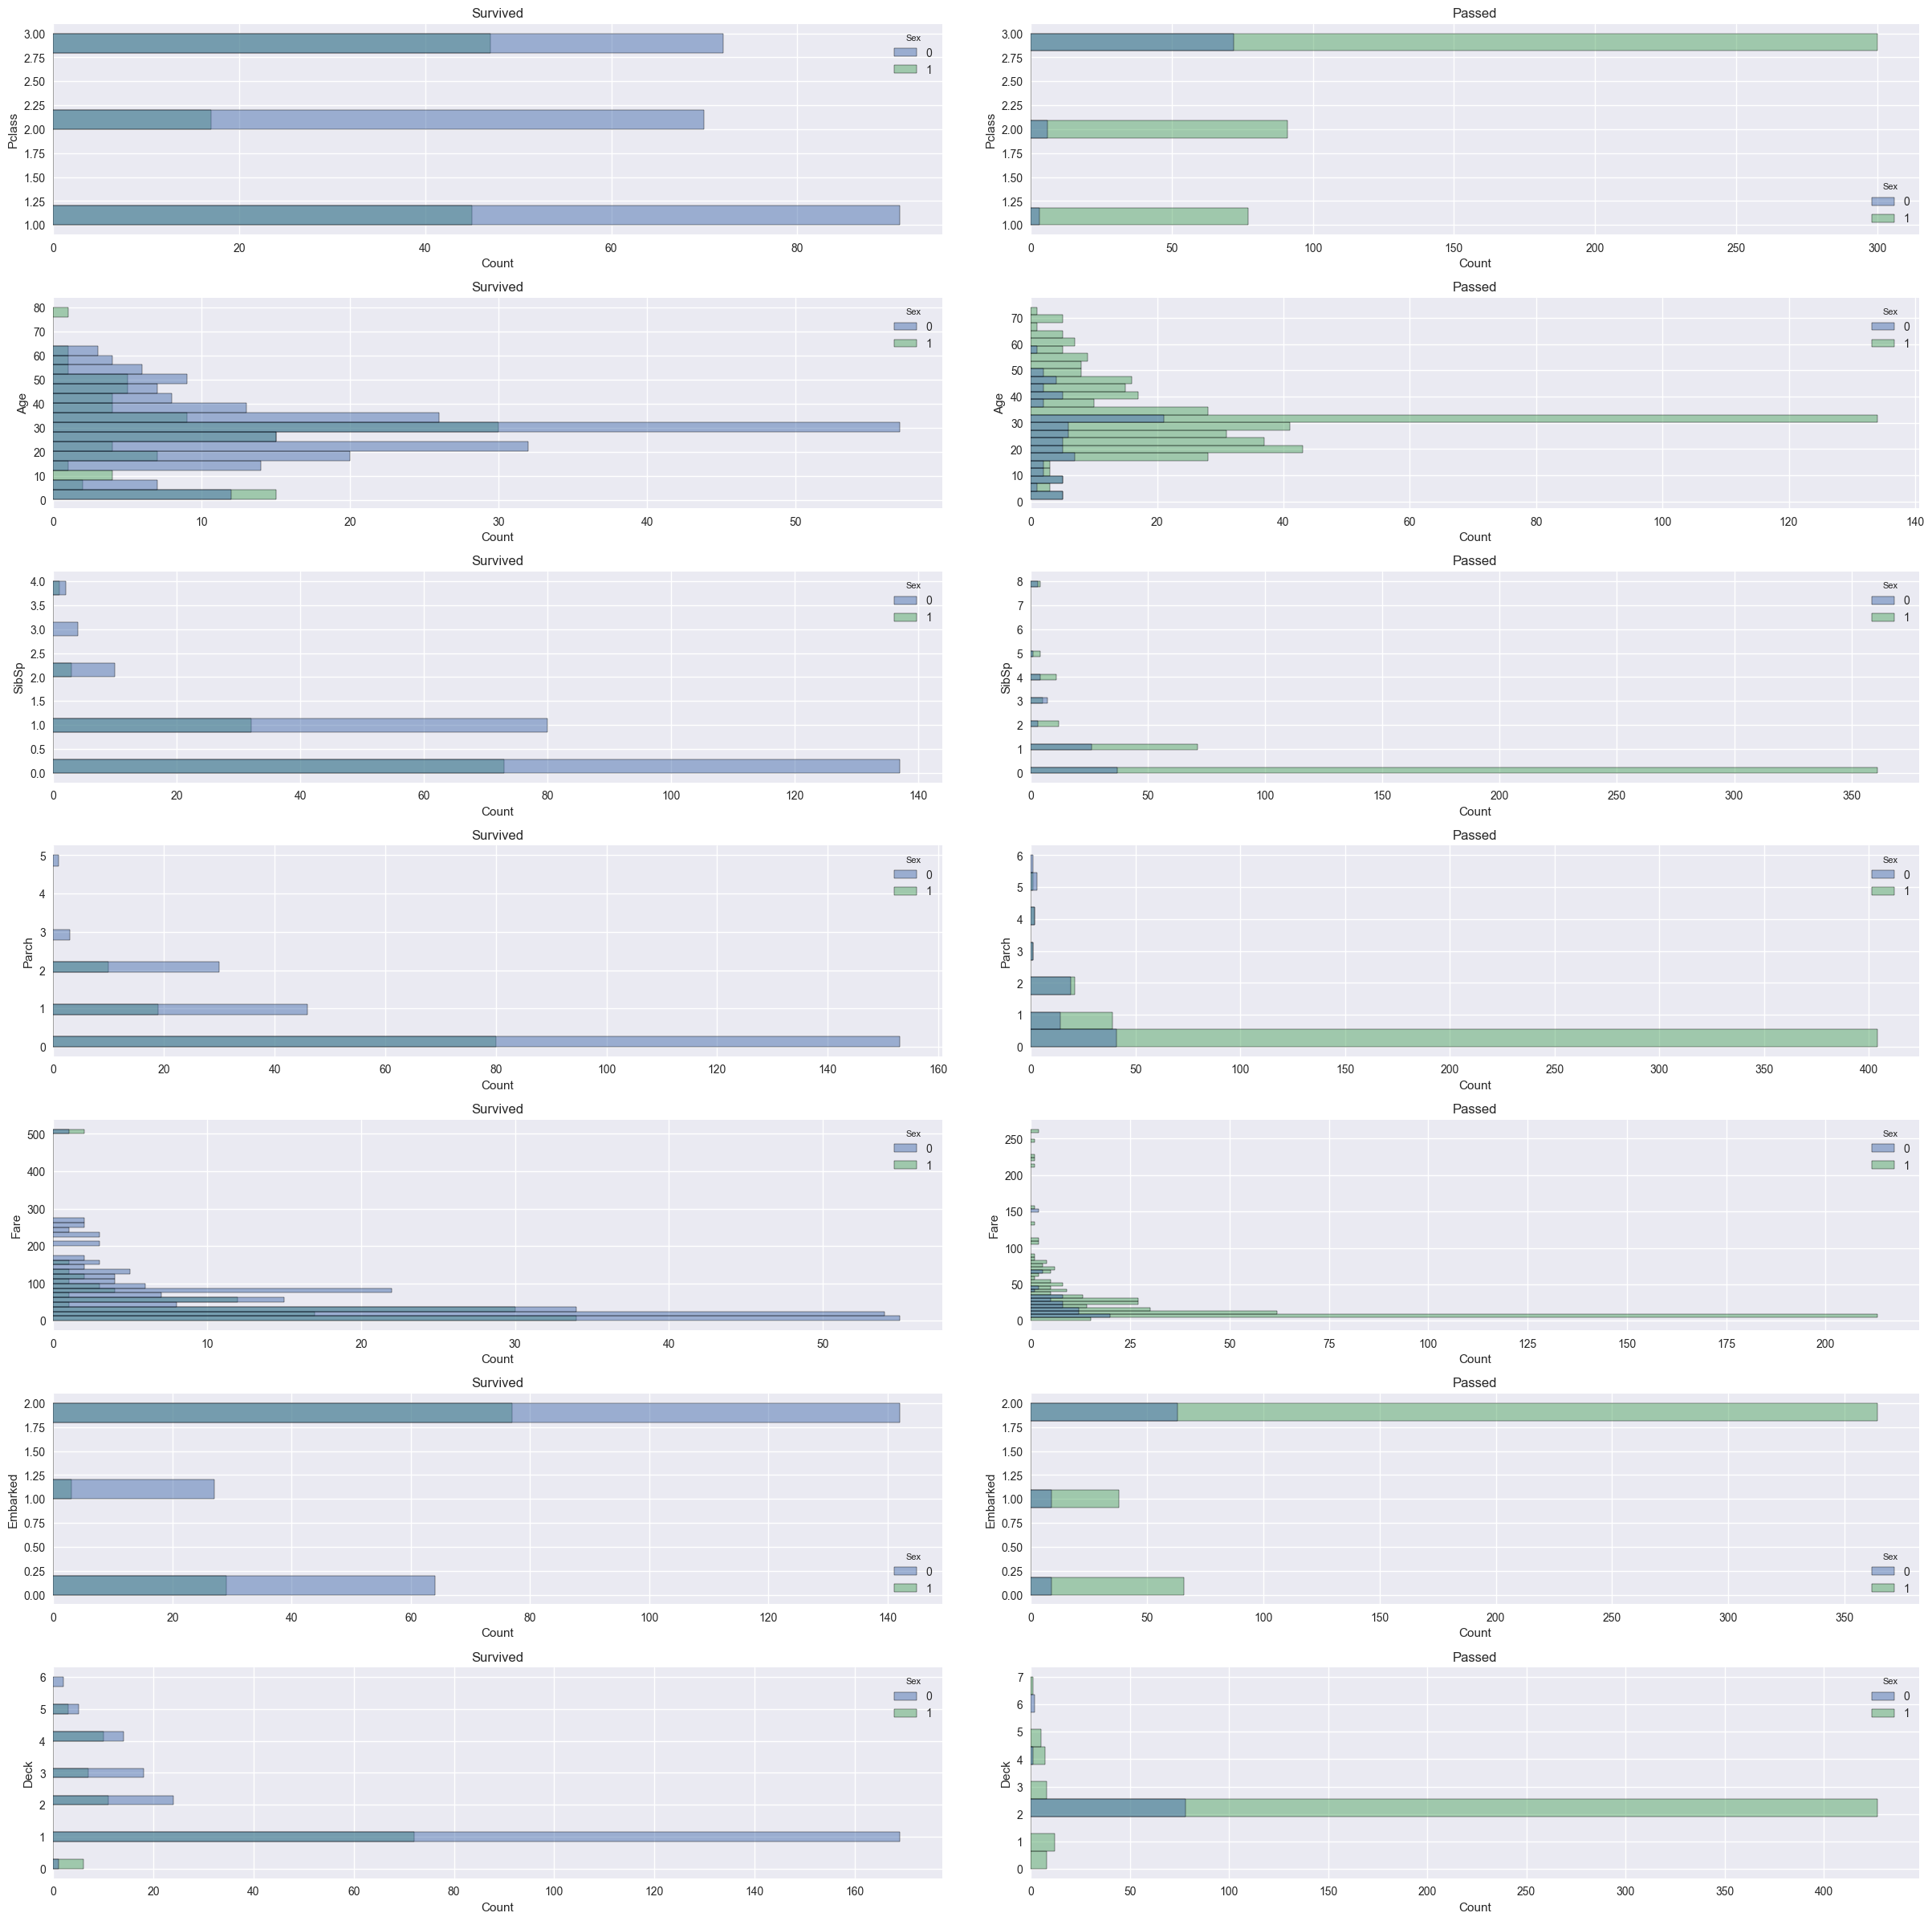

In [12]:
fig = plt.figure(figsize=(30, 30))

cols_visualize = df_survive.columns.drop(['Survived', 'Sex', 'imaginary_ave'])
for i, col in enumerate(cols_visualize):
    ax = fig.add_subplot(7, 2, 2*i+1)
    ax.set_title("Survived")

    sns.histplot(df_survive, y=col, ax=ax, hue='Sex')

for i, col in enumerate(cols_visualize):
    ax = fig.add_subplot(7, 2, 2*i+2)
    ax.set_title("Passed")

    sns.histplot(df_pass, y=col, ax=ax, hue='Sex')

fig.subplots_adjust(wspace=0.1, hspace=0.3)

<Axes: >

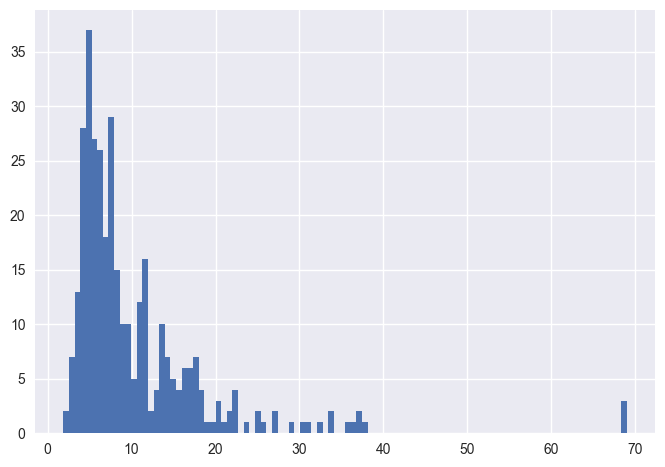

In [13]:
df_survive['imaginary_ave'].hist(bins=100)

<Axes: >

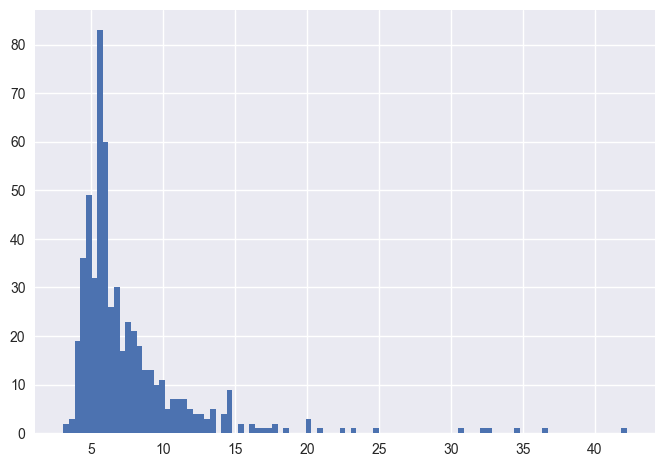

In [14]:
df_pass['imaginary_ave'].hist(bins=100)

In [15]:
# Define similar passengers are ones whose imaginary_ave lies in 45th-quantile to 55th-quantile

def get_sim_pass(df: pd.DataFrame, col_ima: str = 'imaginary_ave',
                 q_low: float = .45, q_up: float = .55):
    x_low, x_up = df[col_ima].quantile(q_low), df[col_ima].quantile(q_up)

    similar = df[(df[col_ima] >= x_low) & (df[col_ima] <= x_up)]

    return similar

get_sim_pass(df_survive)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,imaginary_ave
53,1,2,0,29.00000,1,0,26.0000,2,1,7.625
85,1,3,0,33.00000,3,0,15.8500,2,1,7.23125
98,1,2,0,34.00000,0,1,23.0000,2,1,7.875
109,1,3,0,28.34369,1,0,24.1500,1,1,7.311711
128,1,3,0,28.34369,1,1,22.3583,0,5,7.587749
133,1,2,0,29.00000,1,0,26.0000,2,1,7.625
161,1,2,0,40.00000,0,0,15.7500,2,1,7.59375
211,1,2,0,35.00000,0,0,21.0000,2,1,7.625
279,1,3,0,35.00000,1,1,20.2500,2,1,7.90625
288,1,2,1,42.00000,0,0,13.0000,2,1,7.625


In [16]:
get_sim_pass(df_pass)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,imaginary_ave
4,0,3,1,35.000000,0,0,8.0500,2,2,6.38125
45,0,3,1,30.626179,0,0,8.0500,2,2,5.834522
70,0,2,1,32.000000,0,0,10.5000,2,2,6.1875
73,0,3,1,26.000000,1,0,14.4542,0,2,5.931775
77,0,3,1,30.626179,0,0,8.0500,2,2,5.834522
...,...,...,...,...,...,...,...,...,...,...
850,0,3,1,4.000000,4,2,31.2750,2,2,6.159375
868,0,3,1,30.626179,0,0,9.5000,2,2,6.015772
881,0,3,1,33.000000,0,0,7.8958,2,2,6.111975
886,0,2,1,27.000000,0,0,13.0000,2,2,5.875


4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="background-color: #ccfff2">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="background-color: #ccfff2">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

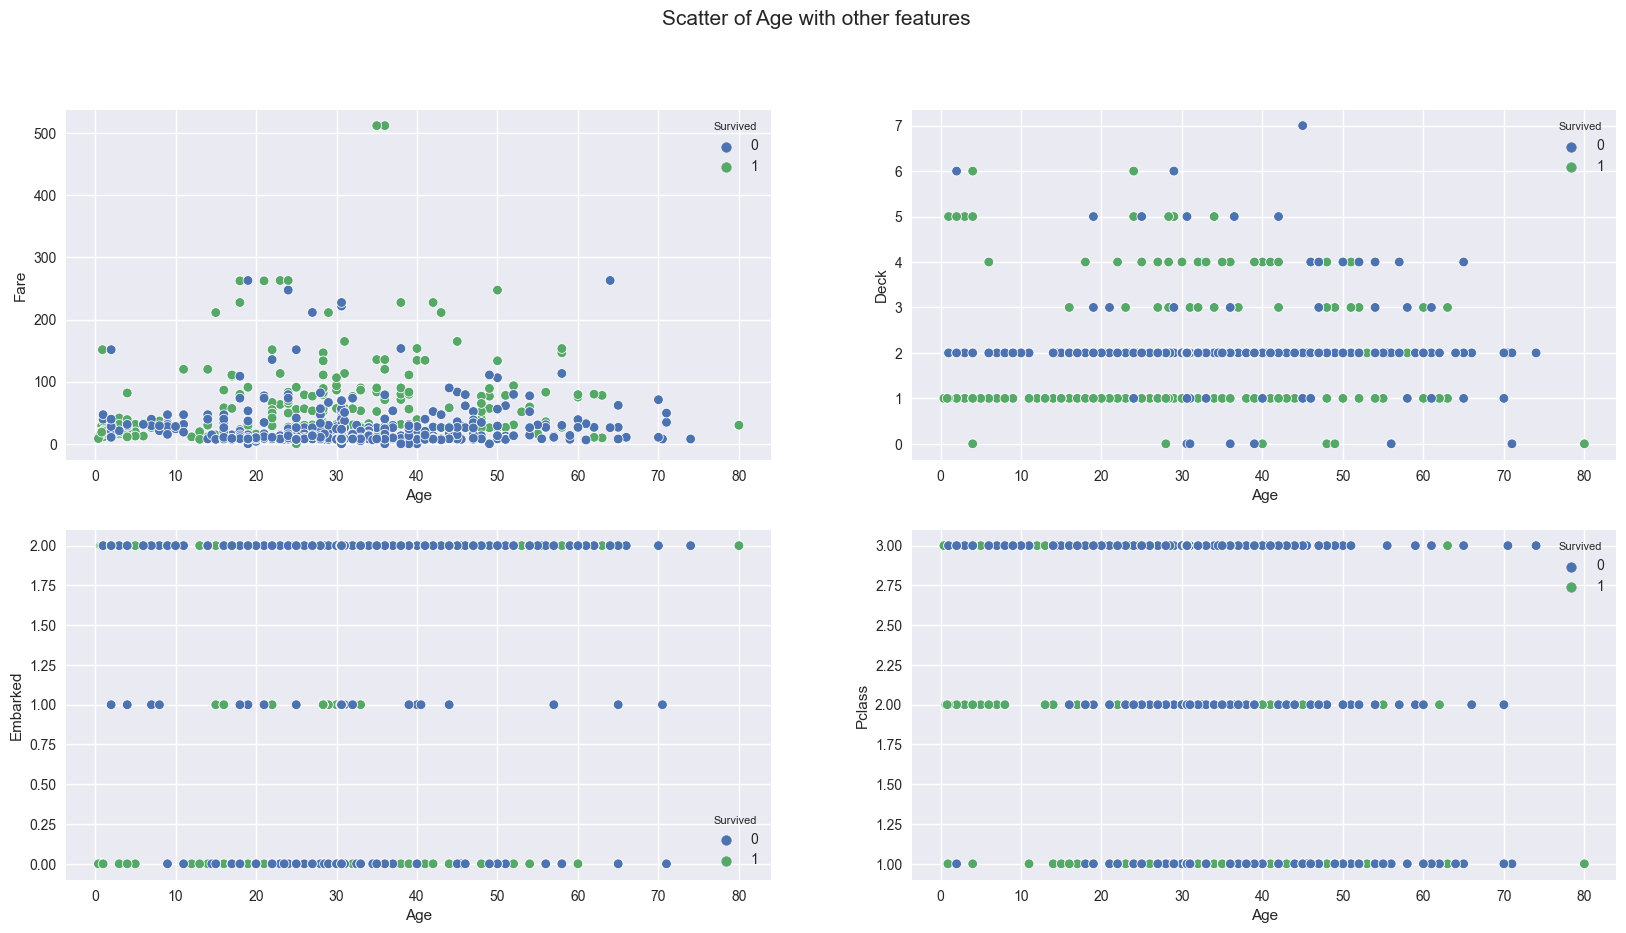

In [17]:
df_tmp = pd.concat([df_survive, df_pass])

fig = plt.figure(figsize=(20, 10))

for i, col in enumerate(['Fare', 'Deck', 'Embarked', 'Pclass']):
    ax = fig.add_subplot(2, 2, i+1)
    sns.scatterplot(df_tmp, x='Age', y=col, hue='Survived', ax=ax)

fig.suptitle("Scatter of Age with other features", fontsize=15)
fig.subplots_adjust(wspace=0.2, hspace=0.2)

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

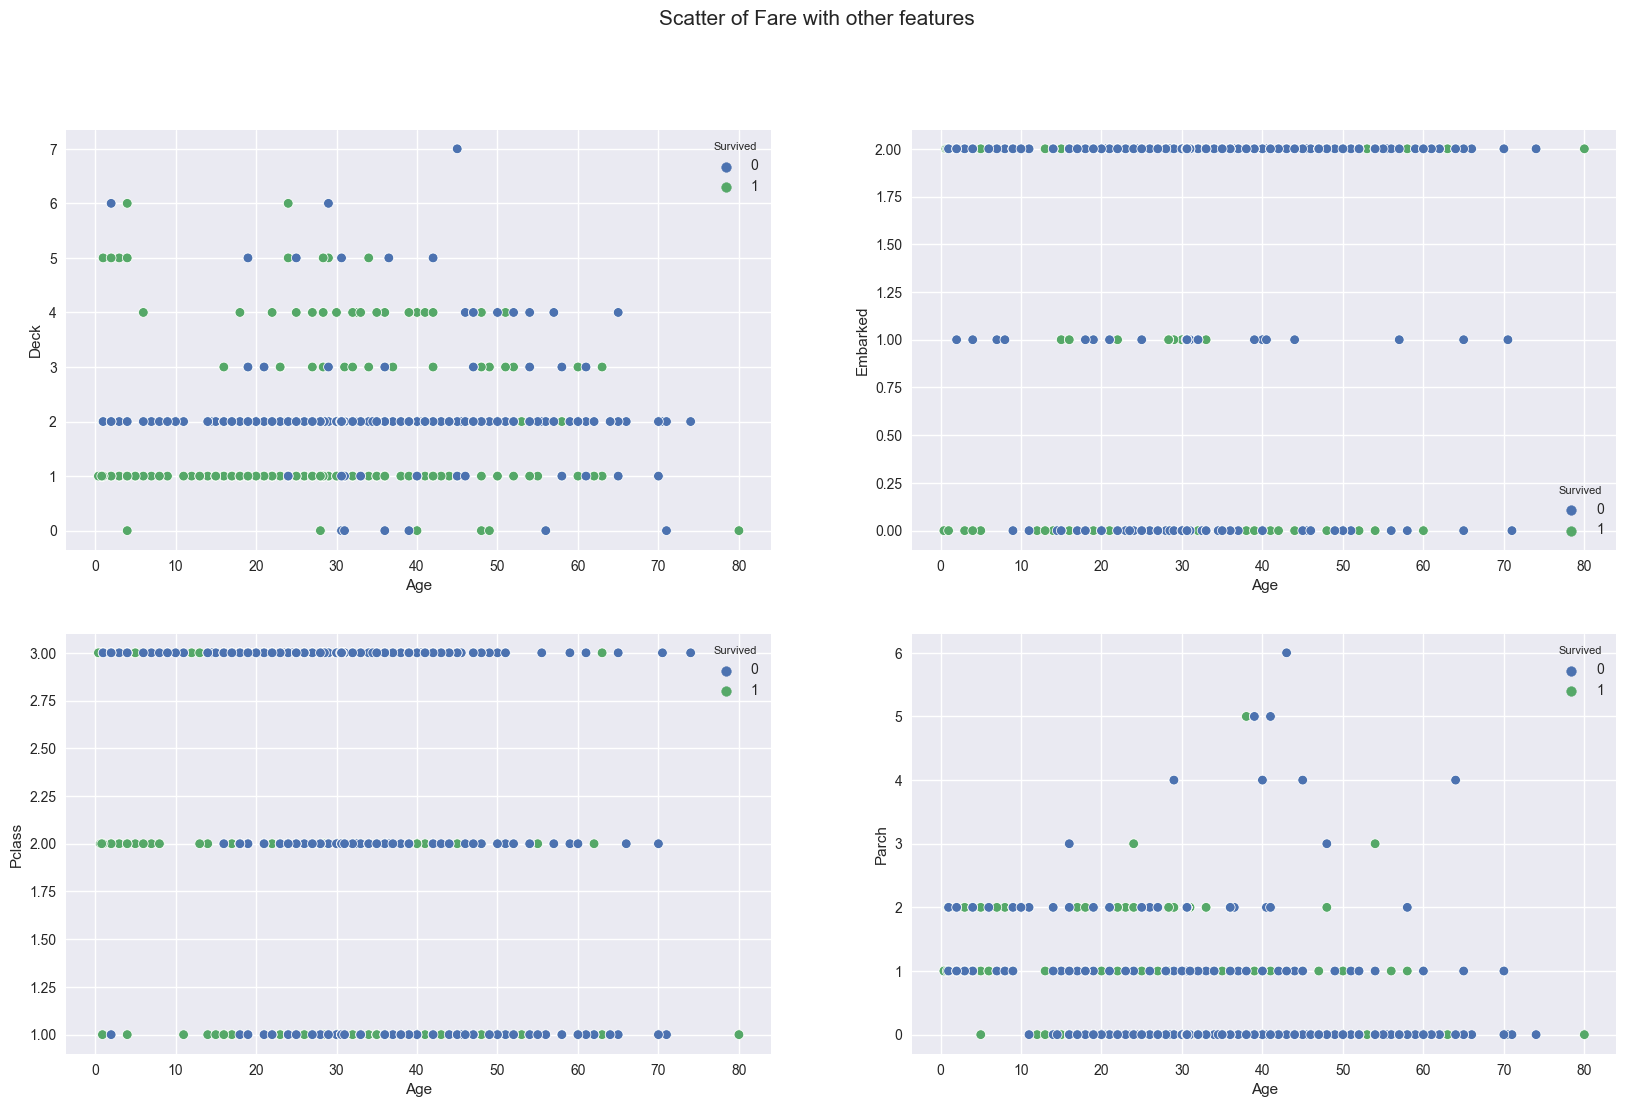

In [18]:
fig = plt.figure(figsize=(20, 12))

fig.suptitle("Scatter of Fare with other features", fontsize=15)
fig.subplots_adjust(wspace=0.2, hspace=0.2)

for i, col in enumerate(['Deck', 'Embarked', 'Pclass', 'Parch']):
    ax = fig.add_subplot(2, 2, i+1)
    sns.scatterplot(df_tmp, x='Age', y=col, hue='Survived', ax=ax)

<Axes: title={'center': 'Passed'}>

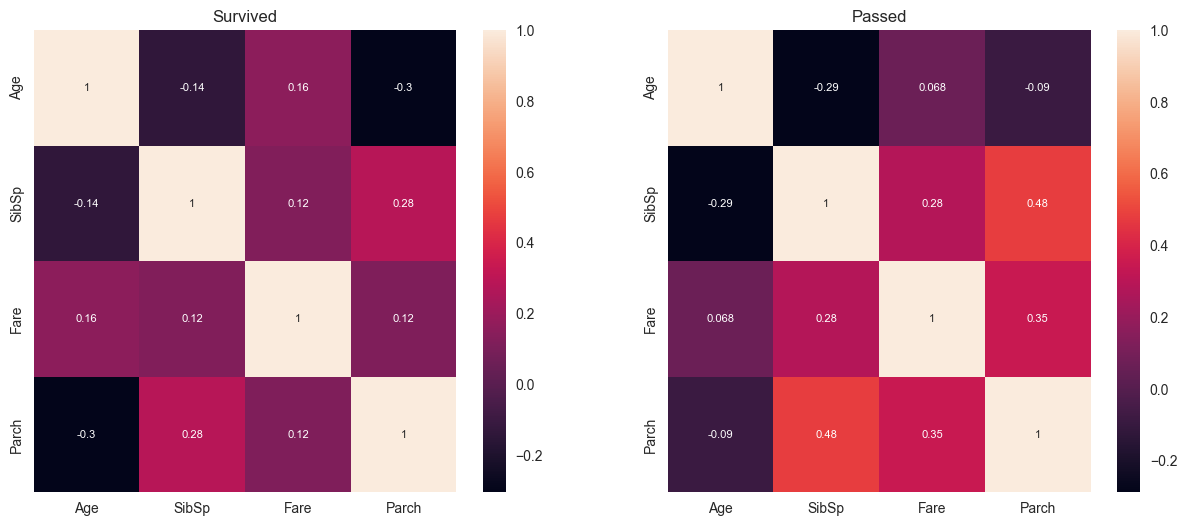

In [19]:
# Draw Pearson heatmap with continuous data
fig = plt.figure(figsize=(15, 6))

ax = fig.add_subplot(121)
ax.set_title('Survived')
sns.heatmap(df_survive[list(cols_num)].corr(), ax=ax, annot=True, annot_kws={'fontsize': 'medium'})


ax = fig.add_subplot(122)
ax.set_title('Passed')
sns.heatmap(df_pass[list(cols_num)].corr(), ax=ax, annot=True, annot_kws={'fontsize': 'medium'})

5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

Here is my answer:

1. The number of rows containing nan-value accounts for a quite significant percentage: up to 15% => nan rows cannot be ignored
2. Imputing data with mean for countinuous features anf mode for categorical ones doesn't affect the overall

**Remember to submit your code on Moodle. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="background-color: #ccfff2">pos.txt</span> and <span style="background-color: #ccfff2">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on Moodle after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [20]:
def get_freq(path: str) -> dict:
    reviews = []
    with open(path) as fp:
        # Extract reviews
        data = fp.readlines()
        for r in data:
            # try:
            reviews.append(json.loads(r)['review'])
            # except Exception:
                # continue

    # Define word frequency
    freq = defaultdict(int)
    for r in reviews:
        words = r.split(' ')
        for w in words:
            freq[w] += 1

    return freq, reviews


path_review_pos, path_review_neg = "reviews_positive_Sep14.json", "reviews_negative_Sep14.json"
freq_pos, rev_pos  = get_freq(path_review_pos)
freq_neg, rev_neg = get_freq(path_review_neg)

most_words_pos = sorted(freq_pos.items(), key=lambda x: x[1], reverse=True)
most_words_neg = sorted(freq_neg.items(), key=lambda x: x[1], reverse=True)

print("Most 30 tokens in positive review: ")
for x in most_words_pos[:30]:
    print(f"{x[0]:<10} --> {x[1]:6d}")
print("Most 30 tokens in negative review: ")
for x in most_words_neg[:30]:
    print(f"{x[0]:<10} --> {x[1]:6d}")

Most 30 tokens in positive review: 
great      --> 439553
work       --> 428544
good       --> 339577
fit        --> 268076
product    --> 211256
easy       --> 187170
look       --> 179583
like       --> 172024
use        --> 165908
buy        --> 158592
light      --> 150005
car        --> 148811
price      --> 145038
need       --> 136690
perfect    --> 124815
time       --> 121722
quality    --> 121266
install    --> 118256
nice       --> 111017
come       -->  91633
well       -->  86021
get        -->  84734
little     -->  83563
instal     -->  81617
new        -->  76835
filter     -->  75567
replace    -->  74815
recommend  -->  74245
go         -->  72800
long       -->  69794
Most 30 tokens in negative review: 
work       -->  40013
fit        -->  30017
buy        -->  29072
product    -->  24370
light      -->  23464
like       -->  20045
time       -->  19563
use        -->  18986
good       -->  18966
look       -->  18644
car        -->  16875
return     -->  15287
try 

2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="background-color: #ccfff2">2 x m</span> matrix, where <span style="background-color: #ccfff2">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="background-color: #ccfff2">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [21]:
def get_tfidf_df(reviews: List[str], ith: int):
    cv = CountVectorizer()
    word_count = cv.fit_transform(reviews)

    tfidf_transformer=TfidfTransformer(smooth_idf=True,use_idf=True) 
    tf_idf_vector = tfidf_transformer.fit_transform(word_count)

    feature_names = cv.get_feature_names_out() 

    assert 0 <= ith < tf_idf_vector.shape[ith]
    first_document_vector=tf_idf_vector[ith] 

    #print the scores 
    df = pd.DataFrame(first_document_vector.T.todense(), index=feature_names, columns=["tfidf"]) 
    df.sort_values(by=["tfidf"],ascending=False)

    return df

reviews = [
    ' '.join(rev_pos),
    ' '.join(rev_neg),
]

df_tfidf_0, df_tfidf_1 = get_tfidf_df(reviews, 0), get_tfidf_df(reviews, 1)

tfidf_vector = np.concatenate((df_tfidf_0.to_numpy(), df_tfidf_1.to_numpy()), axis=-1).T

tfidf_vector.shape

(2, 138979)

3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [22]:
print("=== Positive ===")
print(f"Most 10 words: {[x[0] for x in most_words_pos[:10]]}")
print(f"Most 10 words by TF-IDF: {df_tfidf_0[:10].index.to_list()}")

print("=== Negative ===")
print(f"Most 10 words: {[x[0] for x in most_words_neg[:10]]}")
print(f"Most 10 words by TF-IDF: {df_tfidf_1[:10].index.to_list()}")

print("Conclusion: TF-IDF not work as expected")

=== Positive ===
Most 10 words: ['great', 'work', 'good', 'fit', 'product', 'easy', 'look', 'like', 'use', 'buy']
Most 10 words by TF-IDF: ['00', '000', '0000', '00000', '000000', '00000000', '00000000000000000058', '00000000000002', '00000000004', '00000001']
=== Negative ===
Most 10 words: ['work', 'fit', 'buy', 'product', 'light', 'like', 'time', 'use', 'good', 'look']
Most 10 words by TF-IDF: ['00', '000', '0000', '00000', '000000', '00000000', '00000000000000000058', '00000000000002', '00000000004', '00000001']
Conclusion: TF-IDF not work as expected


4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset. 

    <span style="background-color: #ccfff2">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

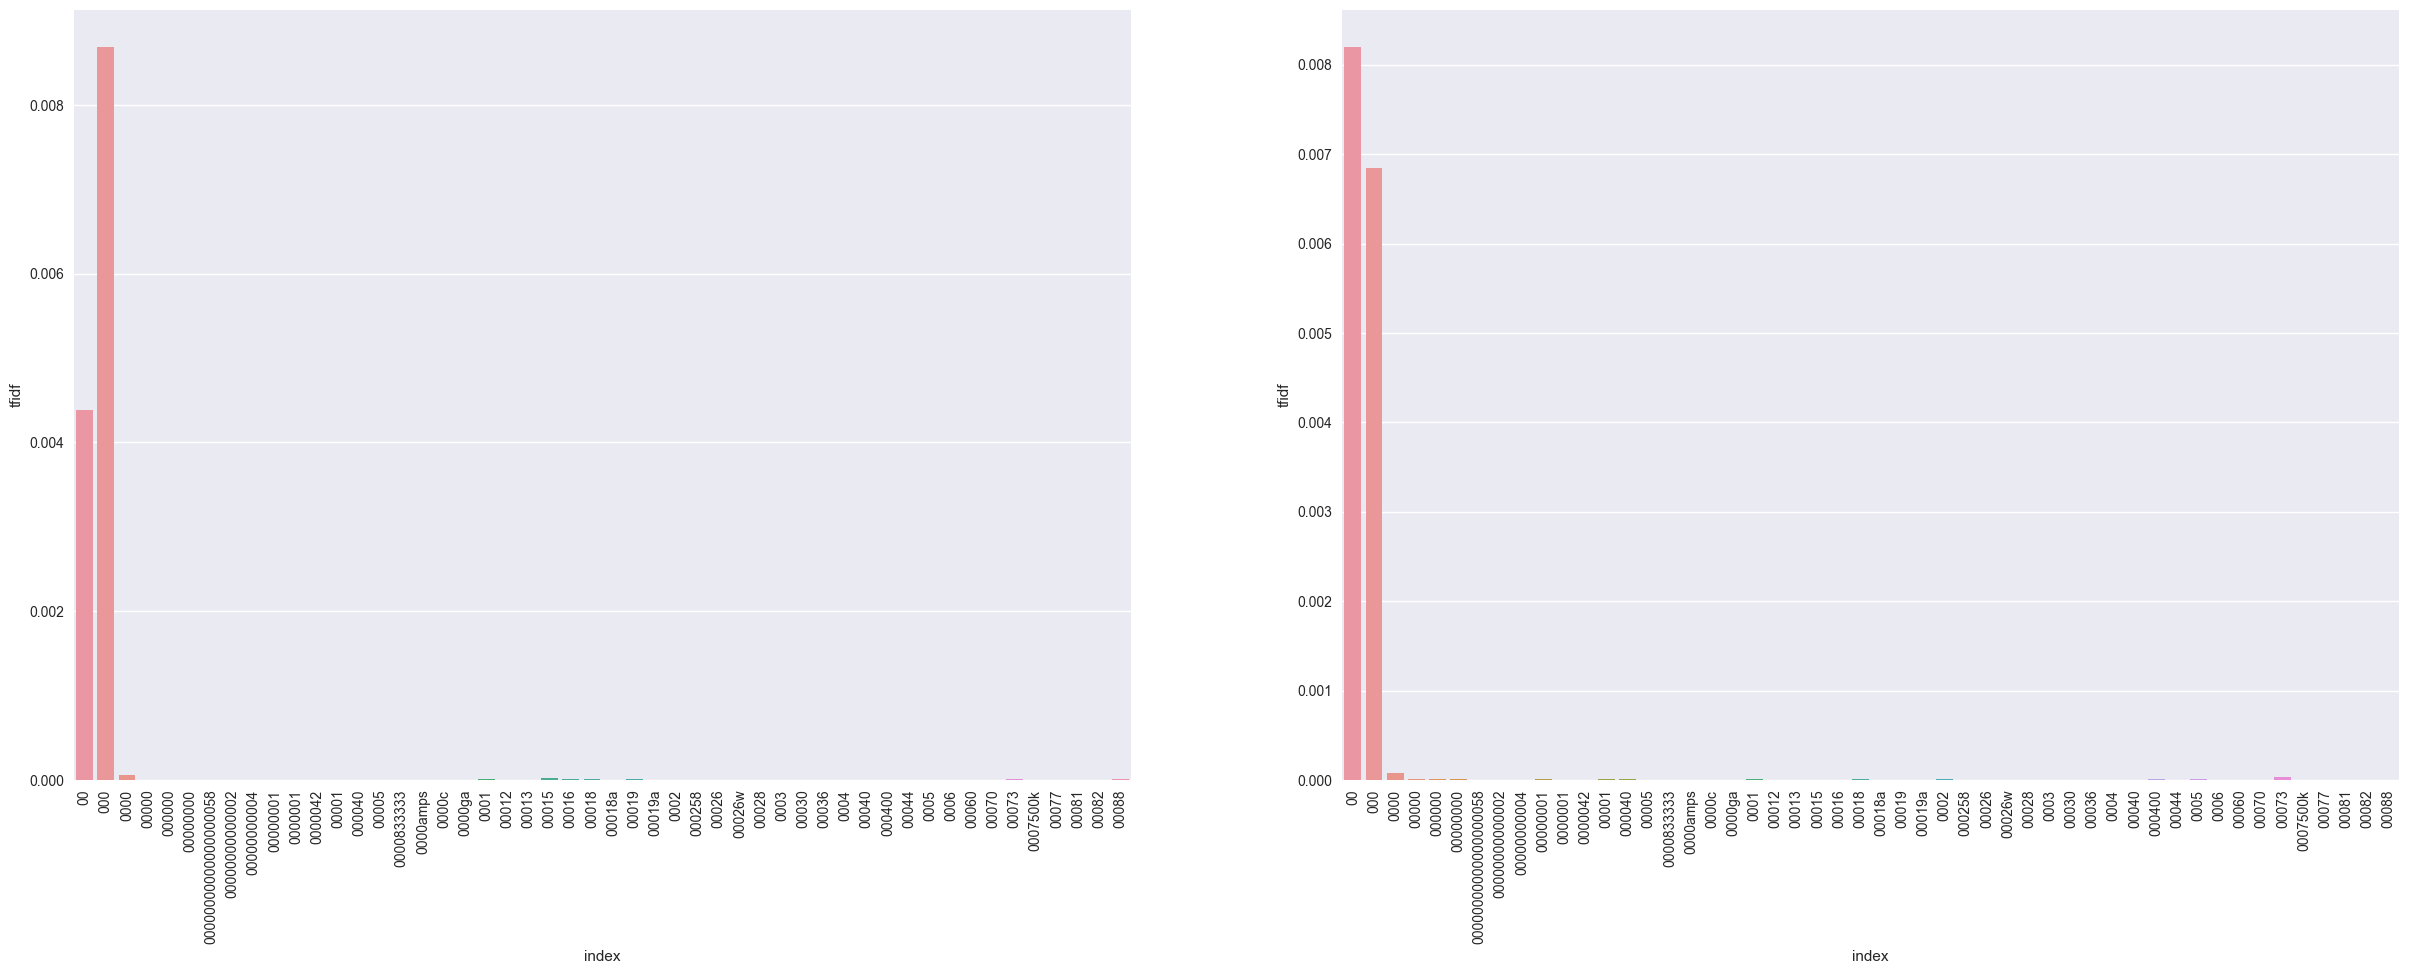

In [24]:
fig = plt.figure(figsize=(30, 10))

ax = fig.add_subplot(121)
sns.barplot(df_tfidf_0[:50].reset_index(), orient='v', ax=ax, y='tfidf', x='index')
ax.tick_params(axis='x', labelrotation = 90)

ax = fig.add_subplot(122)
sns.barplot(df_tfidf_1[:50].reset_index(), orient='v', ax=ax, y='tfidf', x='index')
ax.tick_params(axis='x', labelrotation = 90)

**Remember to submit your code on Moodle. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**